# Proyek Analisis Data: [Bike Sharing Dataset]
- **Nama:** Jelang Ramadhan
- **Email:** cdcc284d6y0574@student.devacademy.id
- **ID Dicoding:** jlaanng

## Menentukan Pertanyaan Bisnis

- Pada musim apa masyarakat menyewa sepeda paling banyak?
- Pada saat jam berapa rental sepeda banyak dikunjungi oleh calon penyewa?
- Bagaimana hubungan antara cuaca dengan jumlah penyewa sepeda?
- Bagaimana strategi promosi yang tepat bisa diterapkan?

## Import Semua Packages/Library yang Digunakan

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

## Data Wrangling

### Gathering Data

Pada tahapan ini kita akan mengumpulkan data data yang akan di analisis

In [2]:
# Memanggil Data dari drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# Memanggil data day.csv
day_df=pd.read_csv("/content/drive/MyDrive/DATA/BIKE/day.csv")
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [4]:
# Memanggil data hour.csv
hour_df=pd.read_csv("/content/drive/MyDrive/DATA/BIKE/hour.csv")
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:**
- Kita mendapatkan informasi tentang data rental sepeda pada tiap harinya
- Kita mendapatkan informasi tentang data rental sepeda pada setiap jamnya

### Assessing Data

Data yang telah di kumpulkan diproses "Gathering Data" akan diperiksa terlebih dahulu sebelum masuk ke tahap analisis.
Ada kemungkinan dataset akan mendapati masalah seperti missing value, data duplicates, dan yang lain lain, proses ini penting dilakuakan
kerena dapat mempengaruhi hasil analisis data.

In [5]:
# Assesing Data day_df
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [6]:
day_df.describe(include="all")

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
unique,NaN,731,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,2012-12-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,366.000000,NaN,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,NaN,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,NaN,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,NaN,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,NaN,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,NaN,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000


In [7]:
# Assesing Data hour_df
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [8]:
hour_df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


In [9]:
# Cek Missing value pada day_df
day_df.isnull().sum()



,0
instant,0
dteday,0
season,0
yr,0
mnth,0
holiday,0
weekday,0
workingday,0
weathersit,0
temp,0


In [10]:
# Cek missing value pada hour_df
hour_df.isnull().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0
weathersit,0


In [11]:
# Cek Duplicate data di day_df
day_df.duplicated().sum()

np.int64(0)

In [12]:
# Cek Duplicate data di hour_df
hour_df.duplicated().sum()

np.int64(0)

**Insight:**
- Ditemuakan format yang tidak sesuai (Invalid Value) pada kolom dteday harusnya dalam datetime pada day_df dan hour_df
- Tidak ditemukan Duplicate Data pada day_df dan hour_df
- Tidak ditemukan Missing Value pada day_df dan hour_df


### Cleaning Data

Setelah kita memeriksa data di proses "Assesing Data," masalah yang ditemukan akan diatasi supaya data dapat dikatakan bersih sebelum proses analisis

In [13]:
# Mengubah format dteday pada day_df
kolom_datetime=["dteday"]

for kolom in kolom_datetime:
  day_df[kolom]=pd.to_datetime(day_df[kolom])

In [14]:
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     731 non-null    int64         
 1   dteday      731 non-null    datetime64[ns]
 2   season      731 non-null    int64         
 3   yr          731 non-null    int64         
 4   mnth        731 non-null    int64         
 5   holiday     731 non-null    int64         
 6   weekday     731 non-null    int64         
 7   workingday  731 non-null    int64         
 8   weathersit  731 non-null    int64         
 9   temp        731 non-null    float64       
 10  atemp       731 non-null    float64       
 11  hum         731 non-null    float64       
 12  windspeed   731 non-null    float64       
 13  casual      731 non-null    int64         
 14  registered  731 non-null    int64         
 15  cnt         731 non-null    int64         
dtypes: datetime64[ns](1), floa

In [15]:
# Mengubah format dteday pada hour_df
kolom_datetime=["dteday"]

for kolom in kolom_datetime:
  hour_df[kolom]=pd.to_datetime(hour_df[kolom])

In [16]:
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     17379 non-null  int64         
 1   dteday      17379 non-null  datetime64[ns]
 2   season      17379 non-null  int64         
 3   yr          17379 non-null  int64         
 4   mnth        17379 non-null  int64         
 5   hr          17379 non-null  int64         
 6   holiday     17379 non-null  int64         
 7   weekday     17379 non-null  int64         
 8   workingday  17379 non-null  int64         
 9   weathersit  17379 non-null  int64         
 10  temp        17379 non-null  float64       
 11  atemp       17379 non-null  float64       
 12  hum         17379 non-null  float64       
 13  windspeed   17379 non-null  float64       
 14  casual      17379 non-null  int64         
 15  registered  17379 non-null  int64         
 16  cnt         17379 non-

**Insight:**
- Masalah Invalid Value telah diselesaian dengan mengubah format dteday dari object ke datetime


## Exploratory Data Analysis (EDA)

Disini kita berada di tahap analisis data untuk menemukan insight dalam data, serta untuk menjawab pertanyaan bisnis pada awal proses analisis

### Mengekploarasi rental sepeda berdasarkan musim

In [17]:
# Melihat persebaran rental sepeda pada setiap musim
day_df.groupby(by="season").cnt.nunique().sort_values(ascending=False)

,cnt
season,
3,188
2,182
1,179
4,176


### Melihat tren untuk menentukan kapan waktu yang sering dikunjungi custumers

In [18]:
# Melihat waktu yang sering dikunjingi custumers
hour_df.groupby(by="hr").cnt.nunique().sort_values(ascending=False)

,cnt
hr,
17,494
18,471
8,467
19,423
16,414
14,385
15,383
12,383
13,377


### Clustering By Wheatersit

In [19]:
hour_df.groupby(by="weathersit").agg({
    "instant": "nunique",
    "cnt": "sum"
}).sort_values(by="cnt", ascending=False)

,instant,cnt
weathersit,,
1,11413,2338173
2,4544,795952
3,1419,158331
4,3,223


**Insight:**
- Ditemukan bahwa rental sepeda pada musim 3 (*fall*)
- Ditemukan bahwa custumers sering merental sepeda pada jam 17.00
- Ditemukan cuaca kategori 1 (*Clear, Few clouds, Partly cloudy, Partly cloudy*) disukai perental sepeda

## Visualization & Explanatory Analysis

Setelah menemukan insight, disini kita akan menyajikan hasilnya ke publik dengan bantuan visual seperti grafik untuk memudahkan penyampaian data.

### Pertanyaan 1:Pada musim apa masyarakat menyewa sepeda paling banyak?

/tmp/ipykernel_668/97855787.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


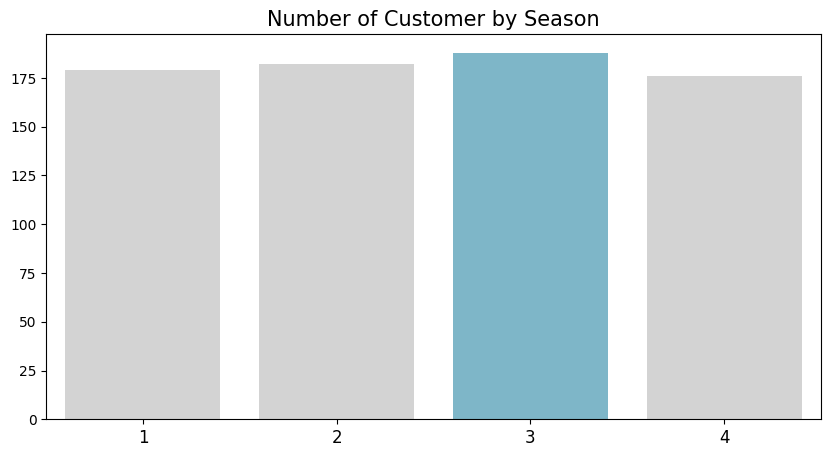

In [20]:
byseason_df = day_df.groupby(by="season").cnt.nunique().reset_index()
byseason_df.rename(columns={
    "cnt": "customer_count"
}, inplace=True)

plt.figure(figsize=(10, 5))
colors_ = ["#D3D3D3",  "#D3D3D3","#72BCD4", "#D3D3D3"]

sns.barplot(
    y="customer_count",
    x="season",
    data=byseason_df.sort_values(by="customer_count", ascending=False),
    palette=colors_
)
plt.title("Number of Customer by Season", loc="center", fontsize=15)
plt.ylabel(None)
plt.xlabel(None)
plt.tick_params(axis='x', labelsize=12)
plt.show()

Keterangan\
  1: Springer\
	2: Summer\
	3: Fall\
	4: Winter

### Pertanyaan 2: Pada saat jam berapa rental sepeda banyak dikunjungi oleh calon penyewa?

/tmp/ipykernel_668/1963259310.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_668/1963259310.py:13: UserWarning: 
The palette list has fewer values (18) than needed (24) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(


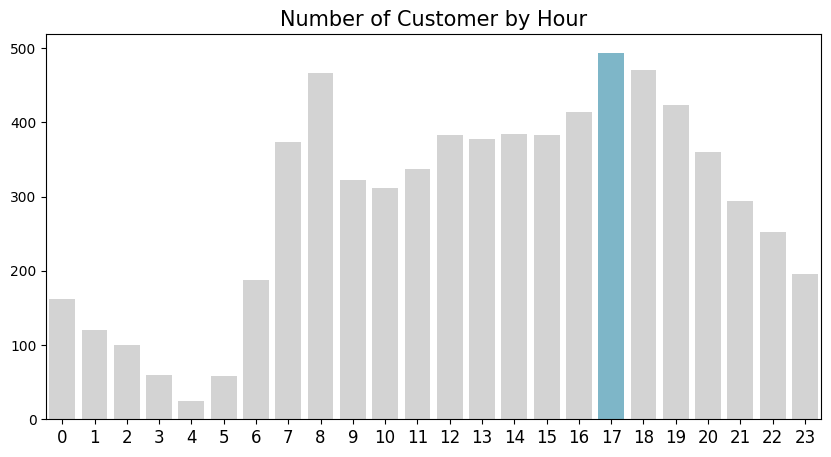

In [21]:
byhour_df = hour_df.groupby(by="hr").cnt.nunique().reset_index()
byhour_df.rename(columns={
    "cnt": "customer_count"
}, inplace=True)

plt.figure(figsize=(10, 5))
colors_ = ["#D3D3D3",  "#D3D3D3", "#D3D3D3","#D3D3D3",  "#D3D3D3", "#D3D3D3",
           "#D3D3D3", "#D3D3D3", "#D3D3D3","#D3D3D3",  "#D3D3D3", "#D3D3D3",
           "#D3D3D3", "#D3D3D3", "#D3D3D3","#D3D3D3",  "#D3D3D3", "#72BCD4"
]


sns.barplot(
    y="customer_count",
    x="hr",
    data=byhour_df.sort_values(by="customer_count", ascending=False),
    palette=colors_
)
plt.title("Number of Customer by Hour", loc="center", fontsize=15)
plt.ylabel(None)
plt.xlabel(None)
plt.tick_params(axis='x', labelsize=12)

plt.show()

### Bagaimana hubungan antara cuaca dengan jumlah penyewa sepeda?

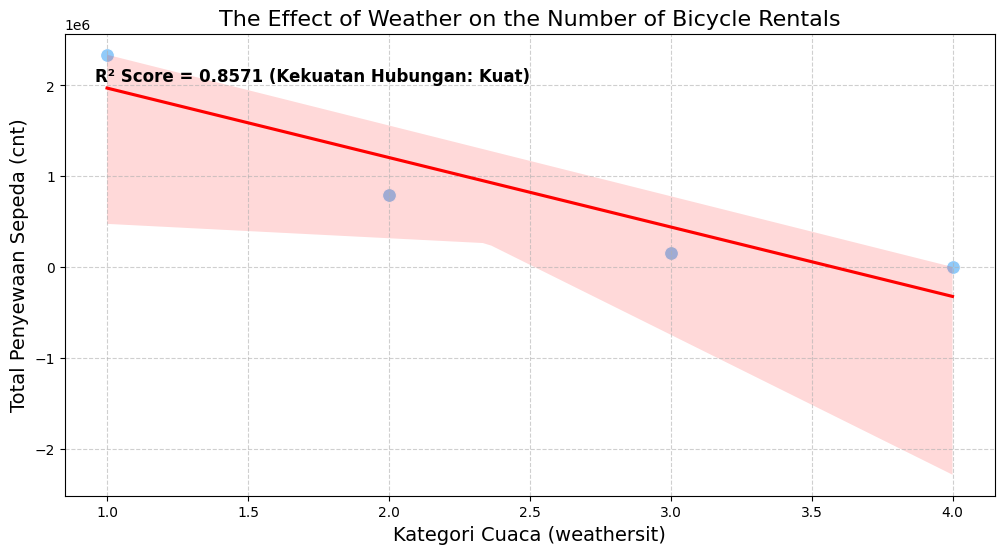

In [22]:
rent = hour_df.groupby(by="weathersit").agg({
    "cnt": "sum"
}).reset_index()

# --- Membuat Scatter Plot dan Garis Regresi
fig, ax = plt.subplots(figsize=(12, 6))

sns.scatterplot(data=rent, x="weathersit", y="cnt", ax=ax, s=100, color="#90CAF9")
sns.regplot(data=rent, x="weathersit", y="cnt", ax=ax, scatter=False, color='red')

model = LinearRegression()
model.fit(rent[["weathersit"]], rent["cnt"])
r2_score = model.score(rent[["weathersit"]], rent["cnt"])

ax.set_title("The Effect of Weather on the Number of Bicycle Rentals", fontsize=16)
ax.set_xlabel("Kategori Cuaca (weathersit)", fontsize=14)
ax.set_ylabel("Total Penyewaan Sepeda (cnt)", fontsize=14)
ax.grid(True, linestyle="--", alpha=0.6)

# --- Menampilkan Nilai R-squared
plt.figtext(0.15, 0.8, f"R² Score = {r2_score:.4f} (Kekuatan Hubungan: {'Kuat' if r2_score > 0.7 else 'Lemah'})",
            fontsize=12, color="black", weight="bold")

plt.show()

**Insight:**
- Diketahui bahwa banyak yang menyewa sepeda pada musim 3 (fall), yaitu sebanyak 188
- Diketahui bahwa pada jam 17.00 merupakan waktu paling banyak penyewa sepeda, yaitu sebanyak 494
- Diketahui bahwa cuaca mempengaruhi jumlah rental sepeda, Karena nilai regresi =  0.8571 (model regresi kuat)

## Analisis Lanjutan

Untuk menjawab pertanyaan terakhir, akan dilakuakn analisis lanjutan berpa clustering. Teknik cluster yang digunakan menggunakan pembagian quartil, sehingga promosi dapat tepat sasaran

In [25]:
features = ['cnt', 'temp', 'hum', 'windspeed']
cluster_data = day_df[features].copy()

# --- Pembagian cluster antar quartil
q1 = cluster_data['cnt'].quantile(0.33)
q2 = cluster_data['cnt'].quantile(0.66)

def demand_cluster(cnt):
    if cnt <= q1:
        return "Low Demand Cluster"
    elif cnt <= q2:
        return "Medium Demand Cluster"
    else:
        return "High Demand Cluster"

# --- Membuat cluster
day_df['Cluster'] = cluster_data['cnt'].apply(demand_cluster)
cluster_summary = day_df.groupby('Cluster').agg(
    cnt_mean=('cnt', 'mean'),
    cnt_min=('cnt', 'min'),
    cnt_max=('cnt', 'max'),
    temp_mean=('temp', 'mean'),
    hum_mean=('hum', 'mean'),
    windspeed_mean=('windspeed', 'mean'),
    n_days=('cnt', 'size')
).reset_index()

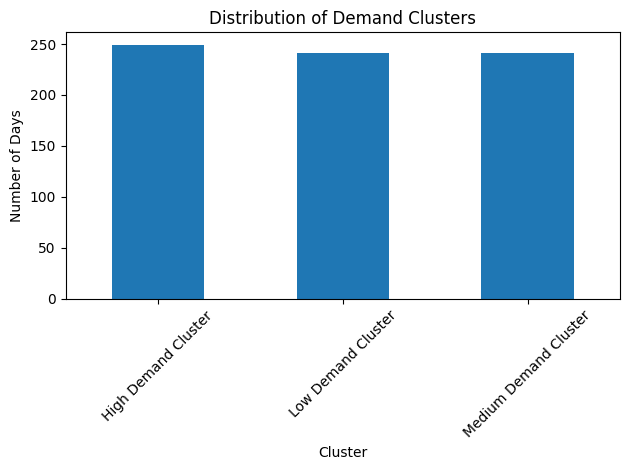

=== Cluster Summary ===
                 Cluster     cnt_mean  cnt_min  cnt_max  temp_mean  hum_mean  \
0    High Demand Cluster  6654.248996     5267     8714   0.593636  0.603257   
1     Low Demand Cluster  2294.439834       22     3709   0.333137  0.633098   
2  Medium Demand Cluster  4492.991701     3717     5260   0.556120  0.648145   

   windspeed_mean  n_days  
0        0.176084     249  
1        0.214307     241  
2        0.181545     241  


In [27]:
# --- Visualisasi cluster
cluster_counts = day_df['Cluster'].value_counts()

plt.figure()
cluster_counts.plot(kind='bar')
plt.title("Distribution of Demand Clusters")
plt.ylabel("Number of Days")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


print("=== Cluster Summary ===")
print(cluster_summary)


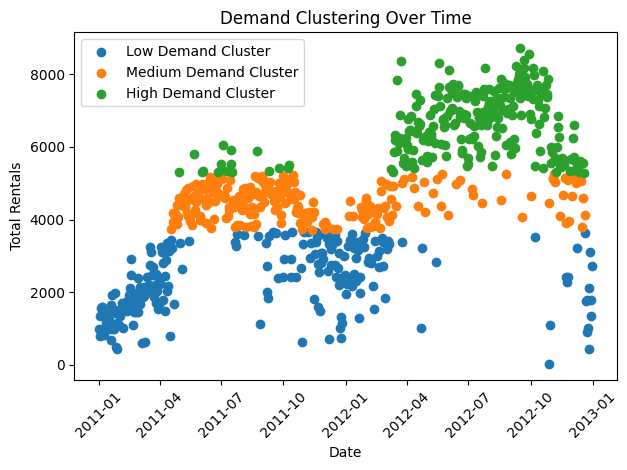

In [31]:
import matplotlib.pyplot as plt

plt.figure()
for cluster in day_df['Cluster'].unique():
    subset = day_df[day_df['Cluster'] == cluster]
    plt.scatter(subset['dteday'], subset['cnt'], label=cluster)

plt.xlabel("Date")
plt.ylabel("Total Rentals")
plt.title("Demand Clustering Over Time")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Insight:**
- Low Demand Cluster : kebanyakan berada pada awal dan akhir tahun 2021, jumlah rental kurang dari 3.700. Hal ini kemungkinan terjadi karena pengaruh suhu dingin yang membuat calon penyewa kurang berminat keluar rumah
- Medium Demand Cluster : kebanyakan terjadi pada pertengahan tahun atau saat musim dingin berakhir sampai masa transisi ke musim dingin. kondisi penjualan stabil diantara 4000-5000.
- High Demand Cluster : terjadi peningkatan penyewaan yang pesat pada pertengahan tahun 2012, puncak penjualan terjadi saat musim panas dengan jumlah penyewaan sampai dengan 8000.

## Conclusion

- Conclution pertanyaan 1:\
Berdasarakan proses analisis yang telah dilakukan, Musim Gugur (Fall) adalah musim dengan penyewa sepeda terbanyak sejumlah 188 penyewa, lalu diikuti dengan musim panas (Summer) dan musim semi (Springer) sebanyak 182 dan 179 penyewa, serta musim yang paling sedikit adalah musim dingin (winter) dengan jumlah 176 penyewa saja. Dengan hasil tersebut, direkomendasikan kepada pemberi jasa untuk memperbanyak kuantitas sepeda untuk disewakan pada musim gugur (Fall).

- Conclution pertanyaan 2 :\
Jam 17.00 merupakan jam favorit para penyewa sepeda dengan jumlah penyewa mencapai 494 penyewa. Dilain sisi, Jam 04.00 adalah jam yang palig sedikit orang yang menyewa sepeda, hanya sebanyak 25 penyewa

- Conclution pertanyaan 3 :\
Dari hasil analisis regresi, nilai yang didapatkan adalah 0.8571 yang menandakan bahwa hubungan antara cuaca dan jumlah penyewa sepeda dapat dikatakan kuat.

- Conclution pertanyaan 4:\
Dari hasil analisis lanjutan menggunakan metode clustering, promosi dapat dilakukan pada masa Low Demand, hal ini berguna untuk meningkatkan tingkat penyewaan sepeda pada musim dingin. Promosi yang dapat dilakukan adalah diskon, pemberian merch natal, atau pemberiaan bantal penghangat untuk bersepeda.

### TO_DASHBOARD


In [32]:
hour_df.to_csv("hour_data.csv", index=False)

In [33]:
day_df.to_csv("day_data.csv", index=False)